In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('..').resolve()
REPORTS_DIR  = PROJECT_ROOT / 'reports'
REPORTS_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi'      : 150,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'xtick.labelsize' : 10,
    'ytick.labelsize' : 10,
    'font.family'     : 'DejaVu Sans',
})

TEAL   = '#1D9E75'
CORAL  = '#D85A30'
PURPLE = '#7F77DD'
GRAY   = '#888780'

df = pd.read_parquet(PROJECT_ROOT / 'data' / 'processed' / 'loans_clean.parquet')
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Default rate: {df['target'].mean():.2%}")
df.head(3)

Loaded: 1,345,350 rows × 34 columns
Default rate: 19.96%


,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,...,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,annual_inc_joint,dti_joint,target,issue_year
0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,...,0.0,2765.0,29.7,13.0,w,Individual,NaN,NaN,0,2015
1,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,...,0.0,21470.0,19.2,38.0,w,Individual,NaN,NaN,0,2015
2,20000.0,20000.0,60 months,10.78,432.66,B,B4,truck driver,10+ years,MORTGAGE,...,0.0,7869.0,56.2,18.0,w,Joint App,71000.0,13.85,0,2015


Cell 2 — Quick data audit before plotting

In [2]:
summary = pd.DataFrame({
    'dtype'    : df.dtypes,
    'null_pct' : (df.isnull().mean() * 100).round(2),
    'n_unique' : df.nunique(),
    'sample'   : df.iloc[0]
})
print(summary.to_string())

                                 dtype  null_pct  n_unique               sample
loan_amnt                      float64      0.00      1556               3600.0
funded_amnt                    float64      0.00      1556               3600.0
term                            object      0.00         2            36 months
int_rate                       float64      0.00       654                13.99
installment                    float64      0.00     83308               123.03
grade                           object      0.00         7                    C
sub_grade                       object      0.00        35                   C4
emp_title                       object      6.38    378358              leadman
emp_length                      object      5.84        11            10+ years
home_ownership                  object      0.00         6             MORTGAGE
annual_inc                     float64      0.00     64362              55000.0
verification_status             object  

Cell 3 — Define numerical and categorical feature lists

In [3]:
NUMERICAL = [
    'loan_amnt', 'int_rate', 'annual_inc', 'dti',
    'fico_range_low', 'fico_range_high', 'revol_util', 'open_acc'
]

CATEGORICAL = [
    'grade', 'sub_grade', 'emp_length', 'home_ownership',
    'purpose', 'addr_state'
]

print("Numerical features :", NUMERICAL)
print("Categorical features:", CATEGORICAL)

Numerical features : ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_range_low', 'fico_range_high', 'revol_util', 'open_acc']
Categorical features: ['grade', 'sub_grade', 'emp_length', 'home_ownership', 'purpose', 'addr_state']


Cell 4 — Distribution plots for all numerical features

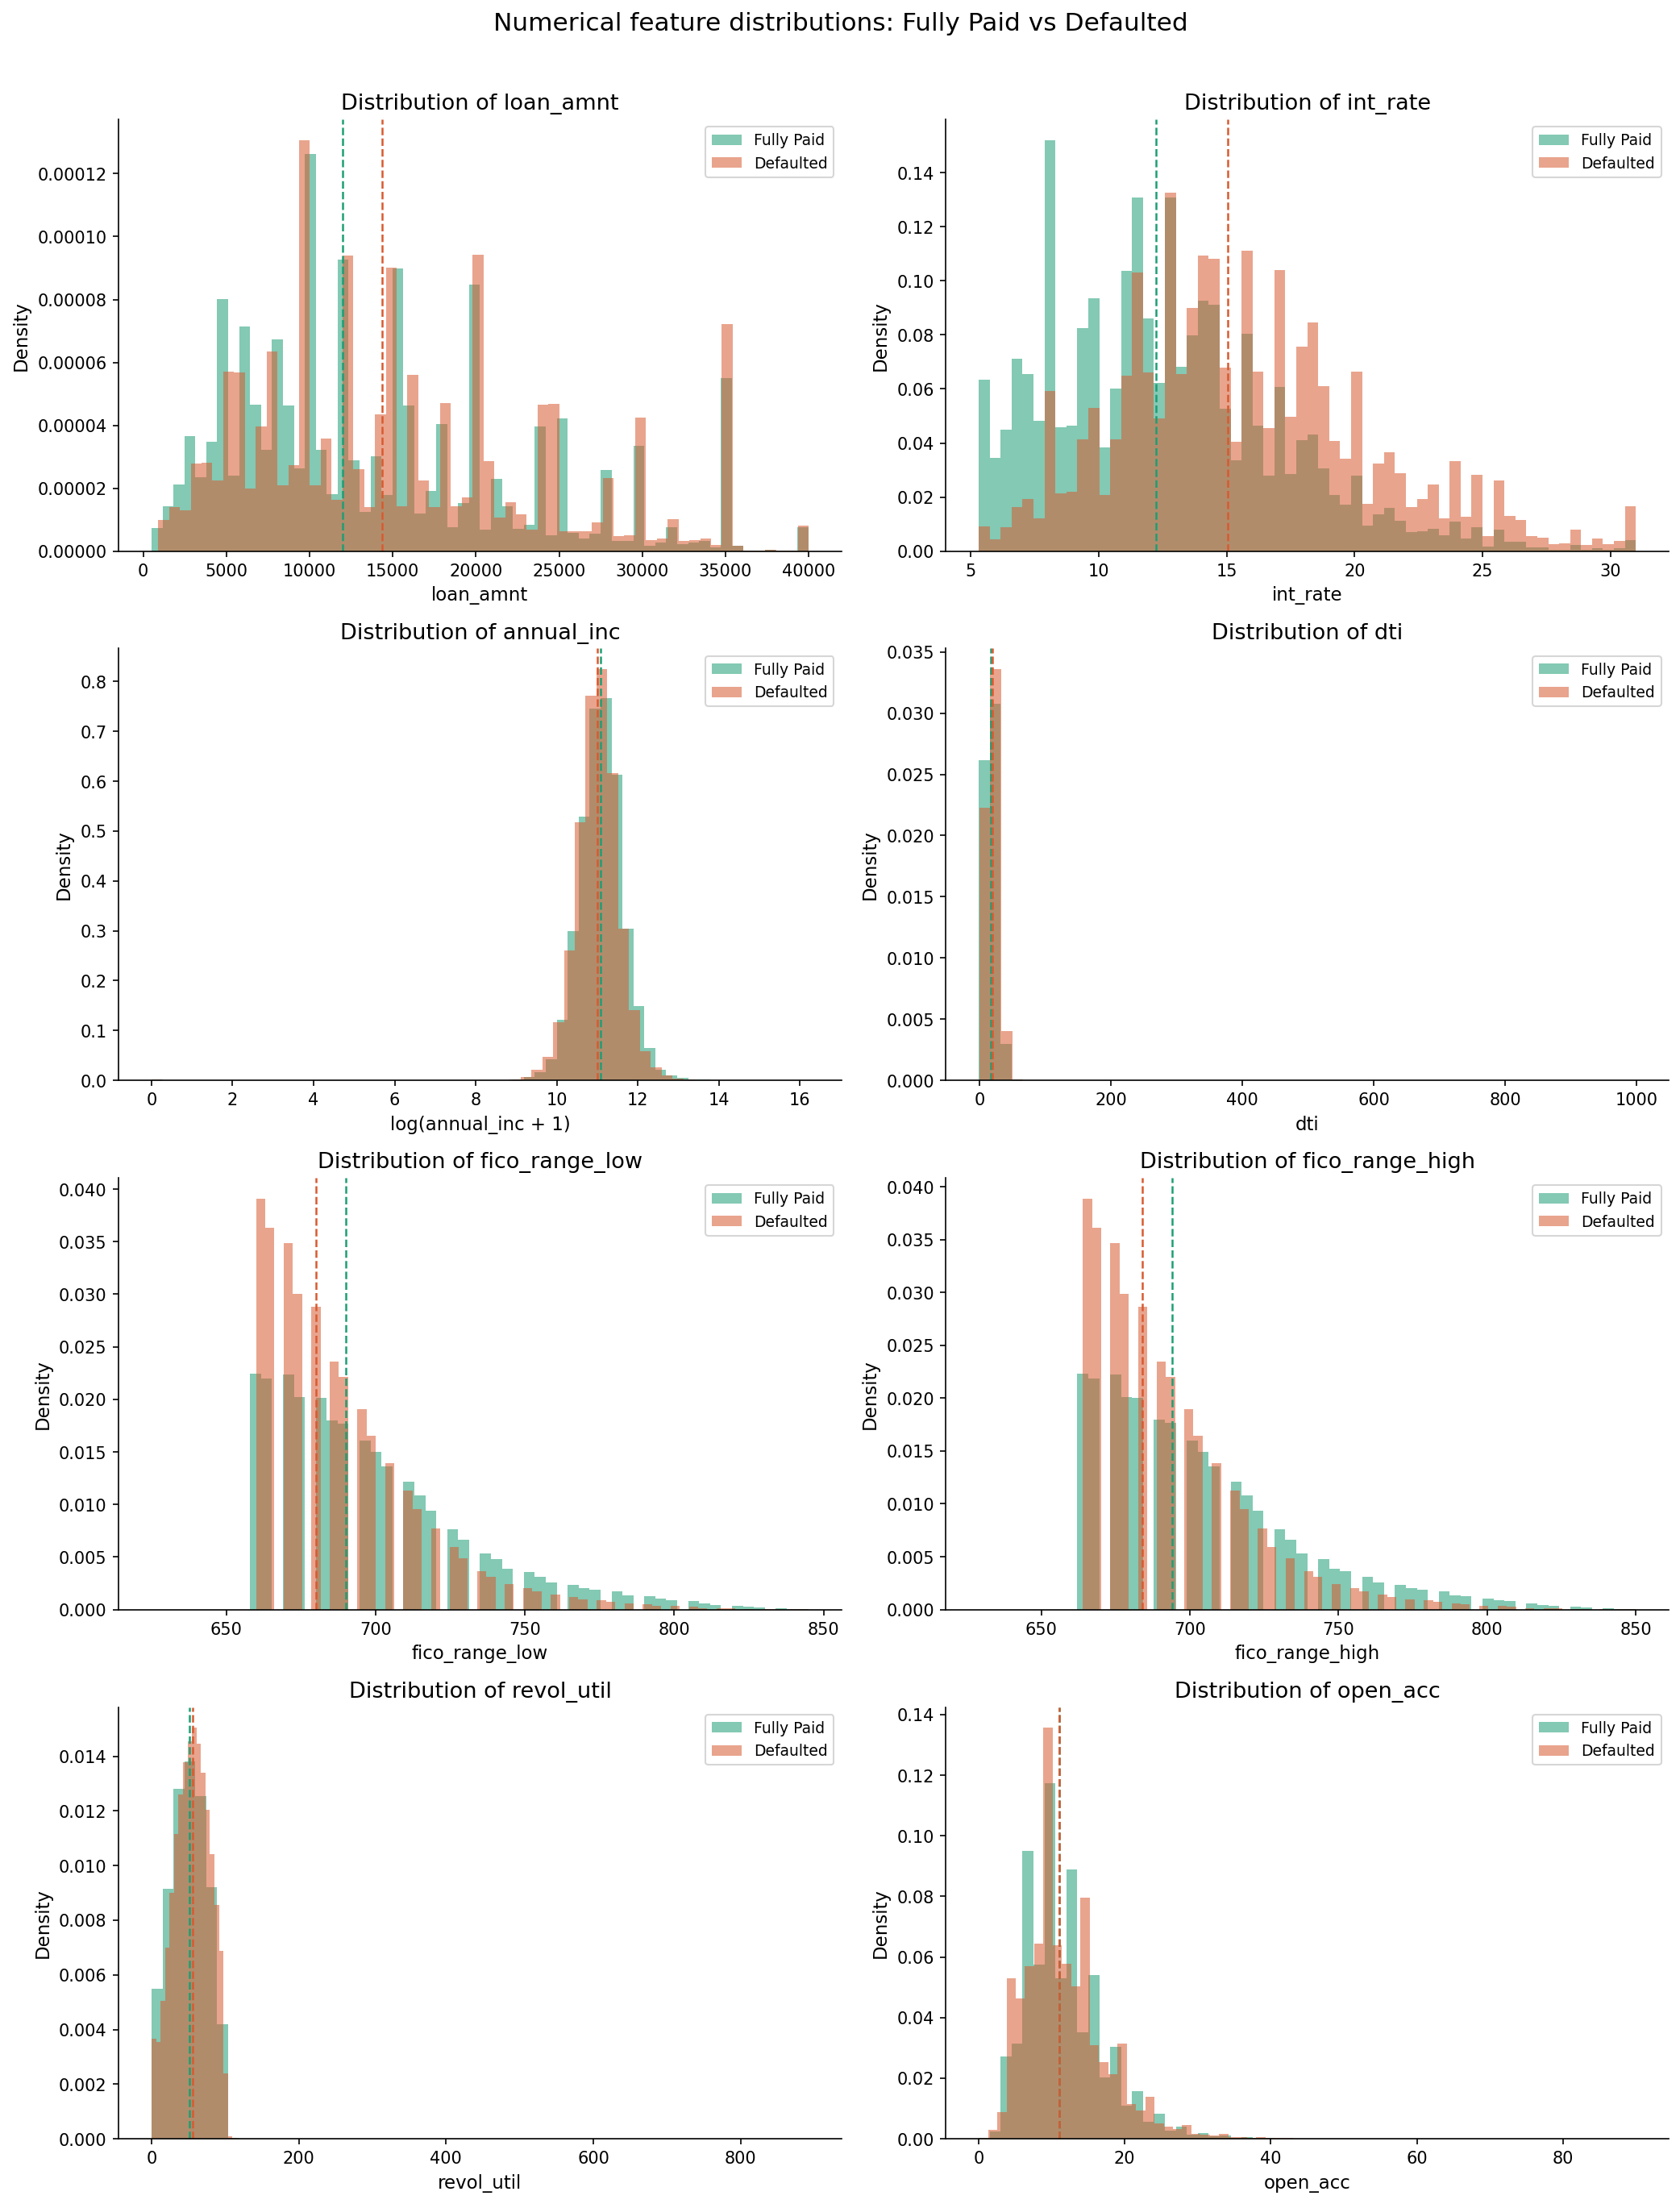

Saved: reports/numerical_distributions.png


In [4]:
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(NUMERICAL):
    ax = axes[i]

    paid     = df[df['target'] == 0][col].dropna()
    defaulted = df[df['target'] == 1][col].dropna()

    # log-scale annual_inc — extreme right skew
    if col == 'annual_inc':
        paid      = np.log1p(paid)
        defaulted = np.log1p(defaulted)
        ax.set_xlabel('log(annual_inc + 1)')
    else:
        ax.set_xlabel(col)

    ax.hist(paid,      bins=60, alpha=0.55, color=TEAL,  label='Fully Paid',  density=True)
    ax.hist(defaulted, bins=60, alpha=0.55, color=CORAL, label='Defaulted',   density=True)

    ax.set_title(f'Distribution of {col}')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

    # annotate medians
    ax.axvline(paid.median(),      color=TEAL,  linestyle='--', linewidth=1.2,
               label=f'Paid median: {paid.median():.1f}')
    ax.axvline(defaulted.median(), color=CORAL, linestyle='--', linewidth=1.2,
               label=f'Default median: {defaulted.median():.1f}')

plt.suptitle('Numerical feature distributions: Fully Paid vs Defaulted',
             fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'numerical_distributions.png', bbox_inches='tight')
plt.show()
print("Saved: reports/numerical_distributions.png")

Cell 5 — Key observations from distributions

In [5]:
print("=== KEY EDA OBSERVATIONS ===\n")

for col in NUMERICAL:
    paid_med     = df[df['target']==0][col].median()
    default_med  = df[df['target']==1][col].median()
    diff_pct     = abs(paid_med - default_med) / paid_med * 100
    direction    = "HIGHER" if default_med > paid_med else "LOWER"
    print(f"{col:20s}  Paid median: {paid_med:>10.2f}  "
          f"Default median: {default_med:>10.2f}  "
          f"→ Defaulters {direction} by {diff_pct:.1f}%")

=== KEY EDA OBSERVATIONS ===

loan_amnt             Paid median:   12000.00  Default median:   14350.00  → Defaulters HIGHER by 19.6%
int_rate              Paid median:      12.23  Default median:      15.05  → Defaulters HIGHER by 23.1%
annual_inc            Paid median:   65000.00  Default median:   60000.00  → Defaulters LOWER by 7.7%
dti                   Paid median:      17.11  Default median:      19.76  → Defaulters HIGHER by 15.5%
fico_range_low        Paid median:     690.00  Default median:     680.00  → Defaulters LOWER by 1.4%
fico_range_high       Paid median:     694.00  Default median:     684.00  → Defaulters LOWER by 1.4%
revol_util            Paid median:      51.30  Default median:      55.50  → Defaulters HIGHER by 8.2%
open_acc              Paid median:      11.00  Default median:      11.00  → Defaulters LOWER by 0.0%


Cell 6 — Default rate by loan grade

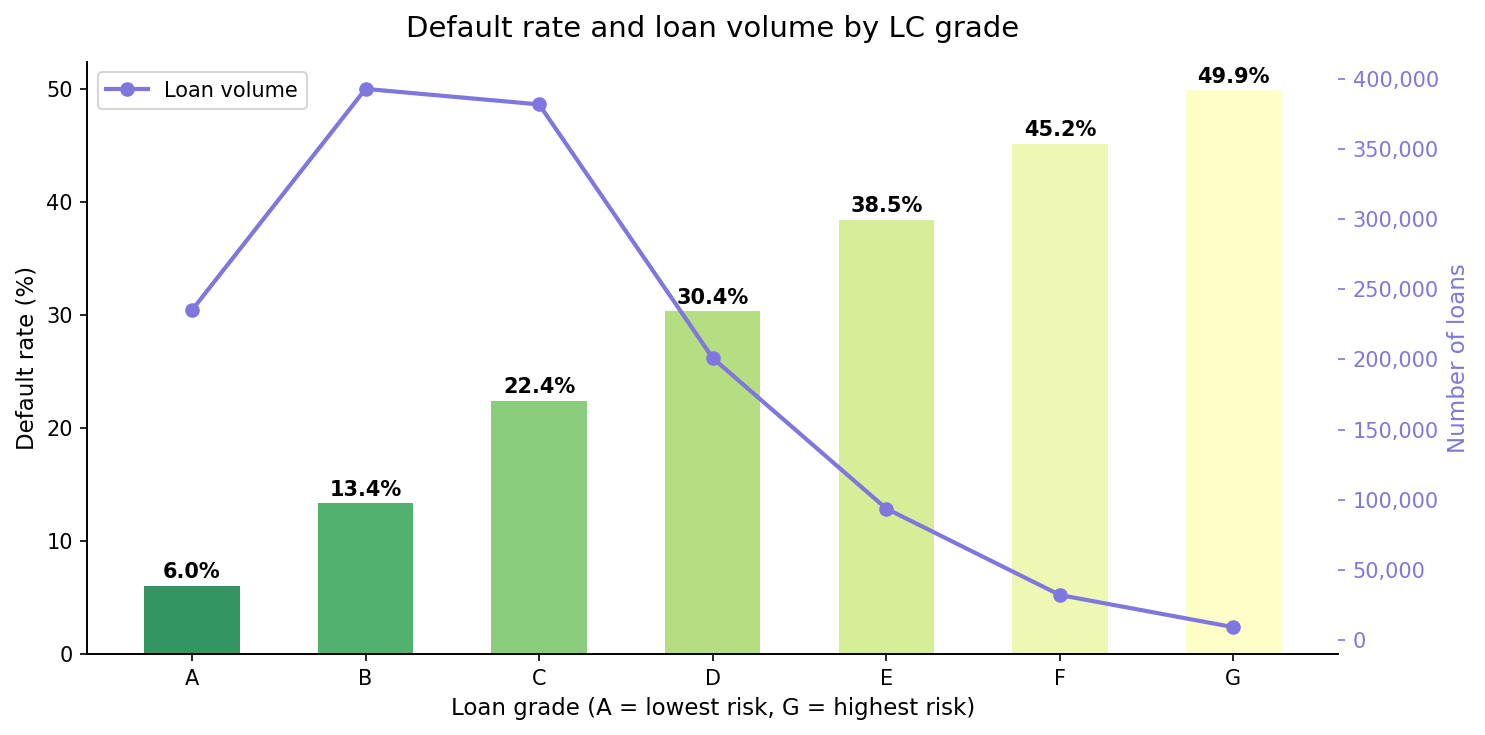


Default rate by grade:
grade  default_rate_pct  total_loans
    A          6.042664       235095
    B         13.386701       392748
    C         22.441275       381694
    D         30.386732       200966
    E         38.482318        93656
    F         45.204155        32059
    G         49.934297         9132


In [6]:
grade_stats = (
    df.groupby('grade')['target']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'default_rate', 'count': 'total_loans'})
    .reset_index()
    .sort_values('grade')
)
grade_stats['default_rate_pct'] = grade_stats['default_rate'] * 100

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

# bar — default rate
bars = ax1.bar(
    grade_stats['grade'],
    grade_stats['default_rate_pct'],
    color=[plt.cm.RdYlGn_r(x / 100) for x in grade_stats['default_rate_pct']],
    width=0.55, alpha=0.85, zorder=2
)

# line — loan volume
ax2.plot(grade_stats['grade'], grade_stats['total_loans'],
         color=PURPLE, marker='o', linewidth=2, markersize=6, label='Loan volume')

# labels on bars
for bar, rate in zip(bars, grade_stats['default_rate_pct']):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{rate:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_xlabel('Loan grade (A = lowest risk, G = highest risk)', fontsize=11)
ax1.set_ylabel('Default rate (%)', color='black')
ax2.set_ylabel('Number of loans', color=PURPLE)
ax2.tick_params(axis='y', colors=PURPLE)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax1.set_title('Default rate and loan volume by LC grade', fontsize=14, pad=12)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'default_rate_by_grade.png', bbox_inches='tight')
plt.show()

print("\nDefault rate by grade:")
print(grade_stats[['grade','default_rate_pct','total_loans']].to_string(index=False))

Cell 7 — Default rate by sub-grade (granular view)

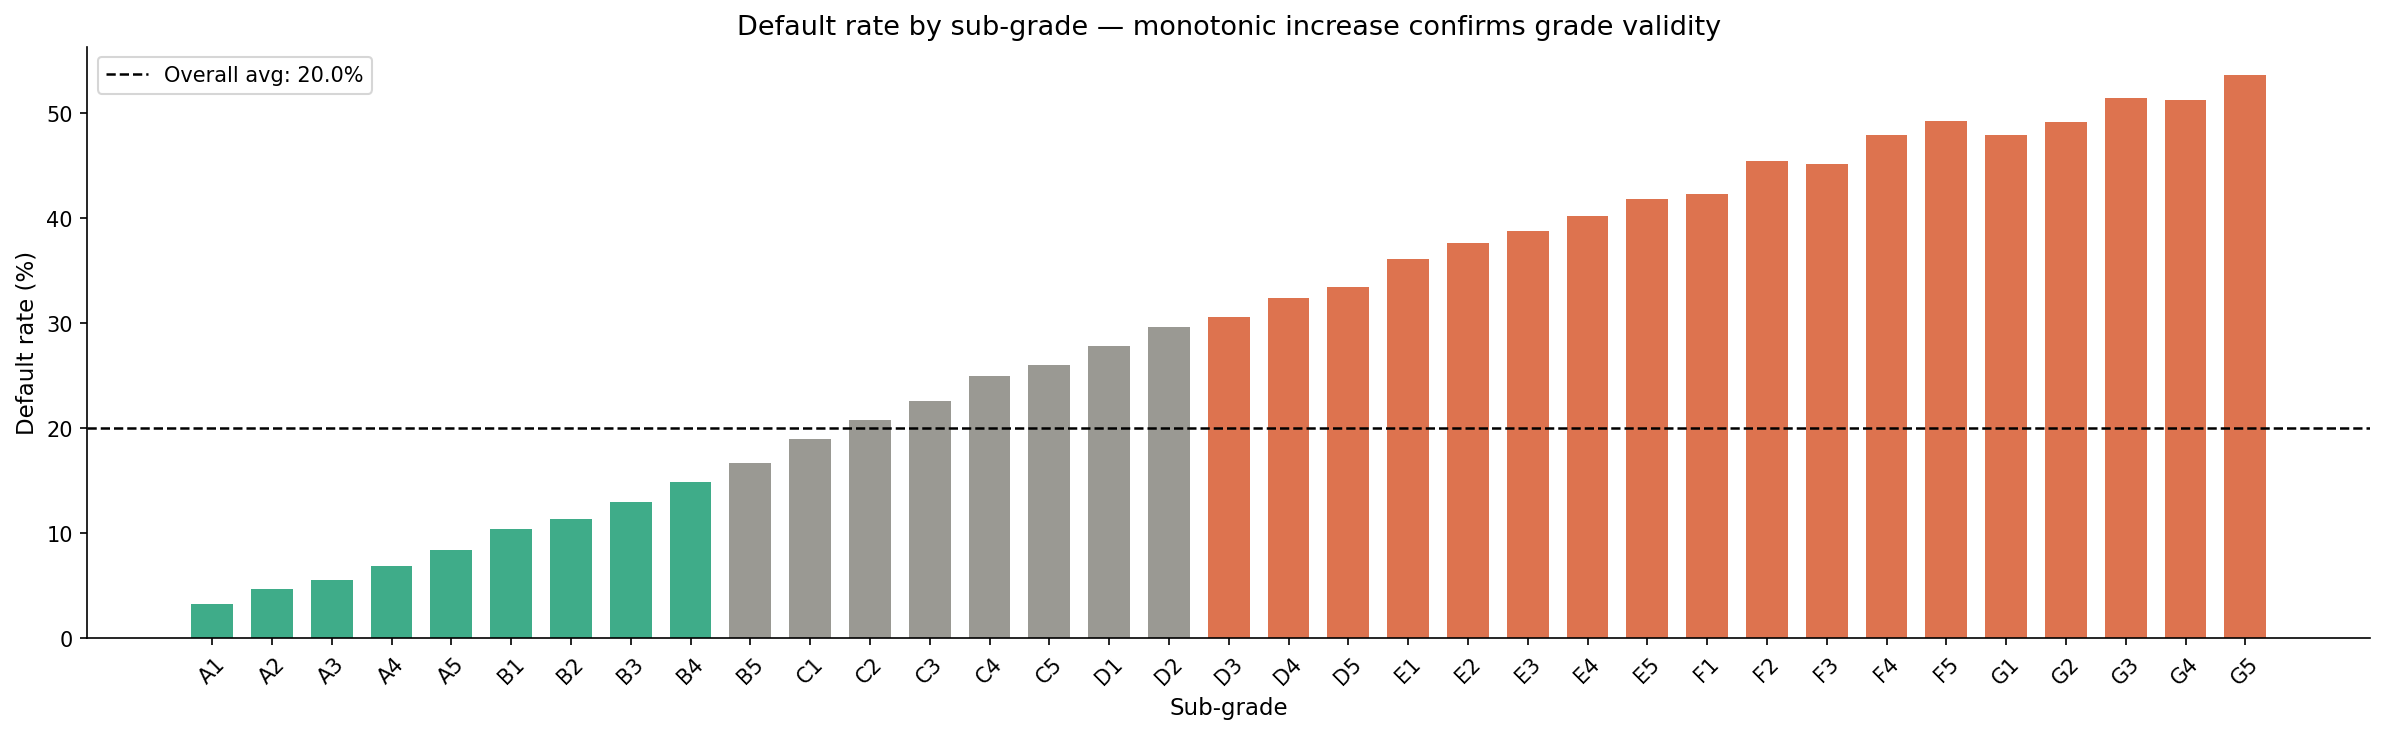

In [7]:
subgrade_stats = (
    df.groupby('sub_grade')['target']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'default_rate', 'count': 'n'})
    .reset_index()
)
subgrade_stats['default_rate_pct'] = subgrade_stats['default_rate'] * 100

fig, ax = plt.subplots(figsize=(16, 5))

colors = [TEAL if r < 15 else CORAL if r > 30 else GRAY
          for r in subgrade_stats['default_rate_pct']]

ax.bar(subgrade_stats['sub_grade'], subgrade_stats['default_rate_pct'],
       color=colors, width=0.7, alpha=0.85)

ax.axhline(df['target'].mean() * 100, color='black', linestyle='--',
           linewidth=1.2, label=f"Overall avg: {df['target'].mean()*100:.1f}%")

ax.set_xlabel('Sub-grade')
ax.set_ylabel('Default rate (%)')
ax.set_title('Default rate by sub-grade — monotonic increase confirms grade validity',
             fontsize=13)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'default_rate_by_subgrade.png', bbox_inches='tight')
plt.show()

Cell 8 — Default rate by loan purpose

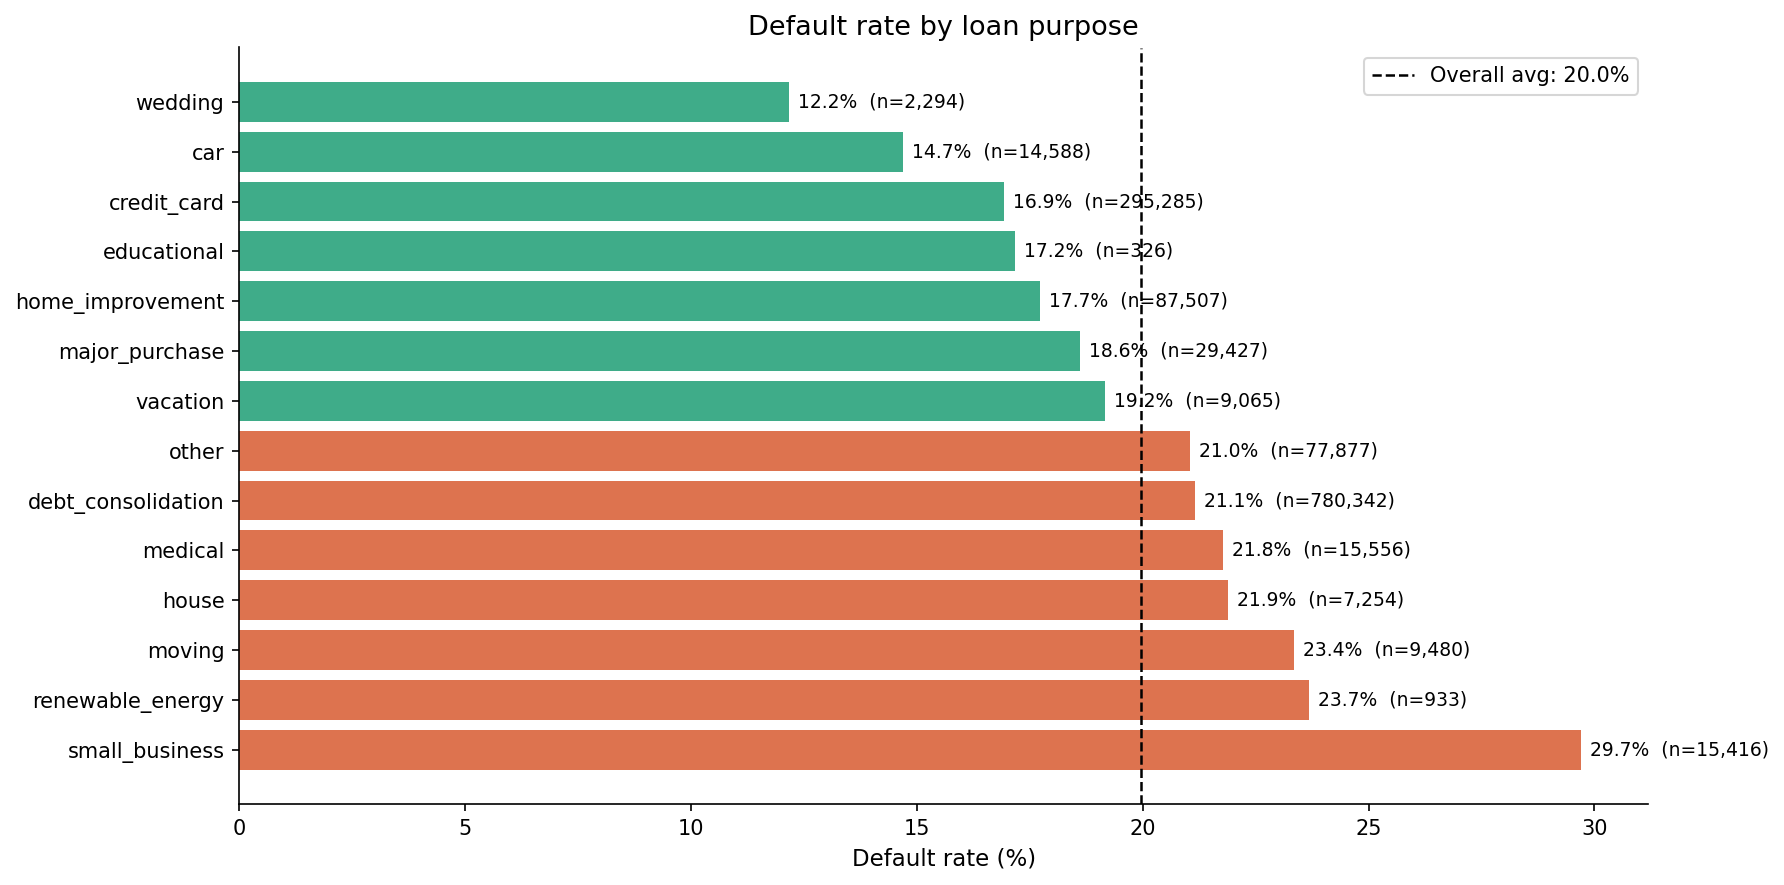

In [8]:
purpose_stats = (
    df.groupby('purpose')['target']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'default_rate', 'count': 'n'})
    .reset_index()
    .sort_values('default_rate', ascending=False)
)
purpose_stats['default_rate_pct'] = purpose_stats['default_rate'] * 100

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(purpose_stats['purpose'], purpose_stats['default_rate_pct'],
               color=[CORAL if r > df['target'].mean()*100 else TEAL
                      for r in purpose_stats['default_rate_pct']],
               alpha=0.85)

ax.axvline(df['target'].mean() * 100, color='black', linestyle='--',
           linewidth=1.2, label=f"Overall avg: {df['target'].mean()*100:.1f}%")

for bar, (_, row) in zip(bars, purpose_stats.iterrows()):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f"{row['default_rate_pct']:.1f}%  (n={row['n']:,})",
            va='center', fontsize=9)

ax.set_xlabel('Default rate (%)')
ax.set_title('Default rate by loan purpose', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'default_rate_by_purpose.png', bbox_inches='tight')
plt.show()

Cell 9 — Correlation heatmap (numerical features only)


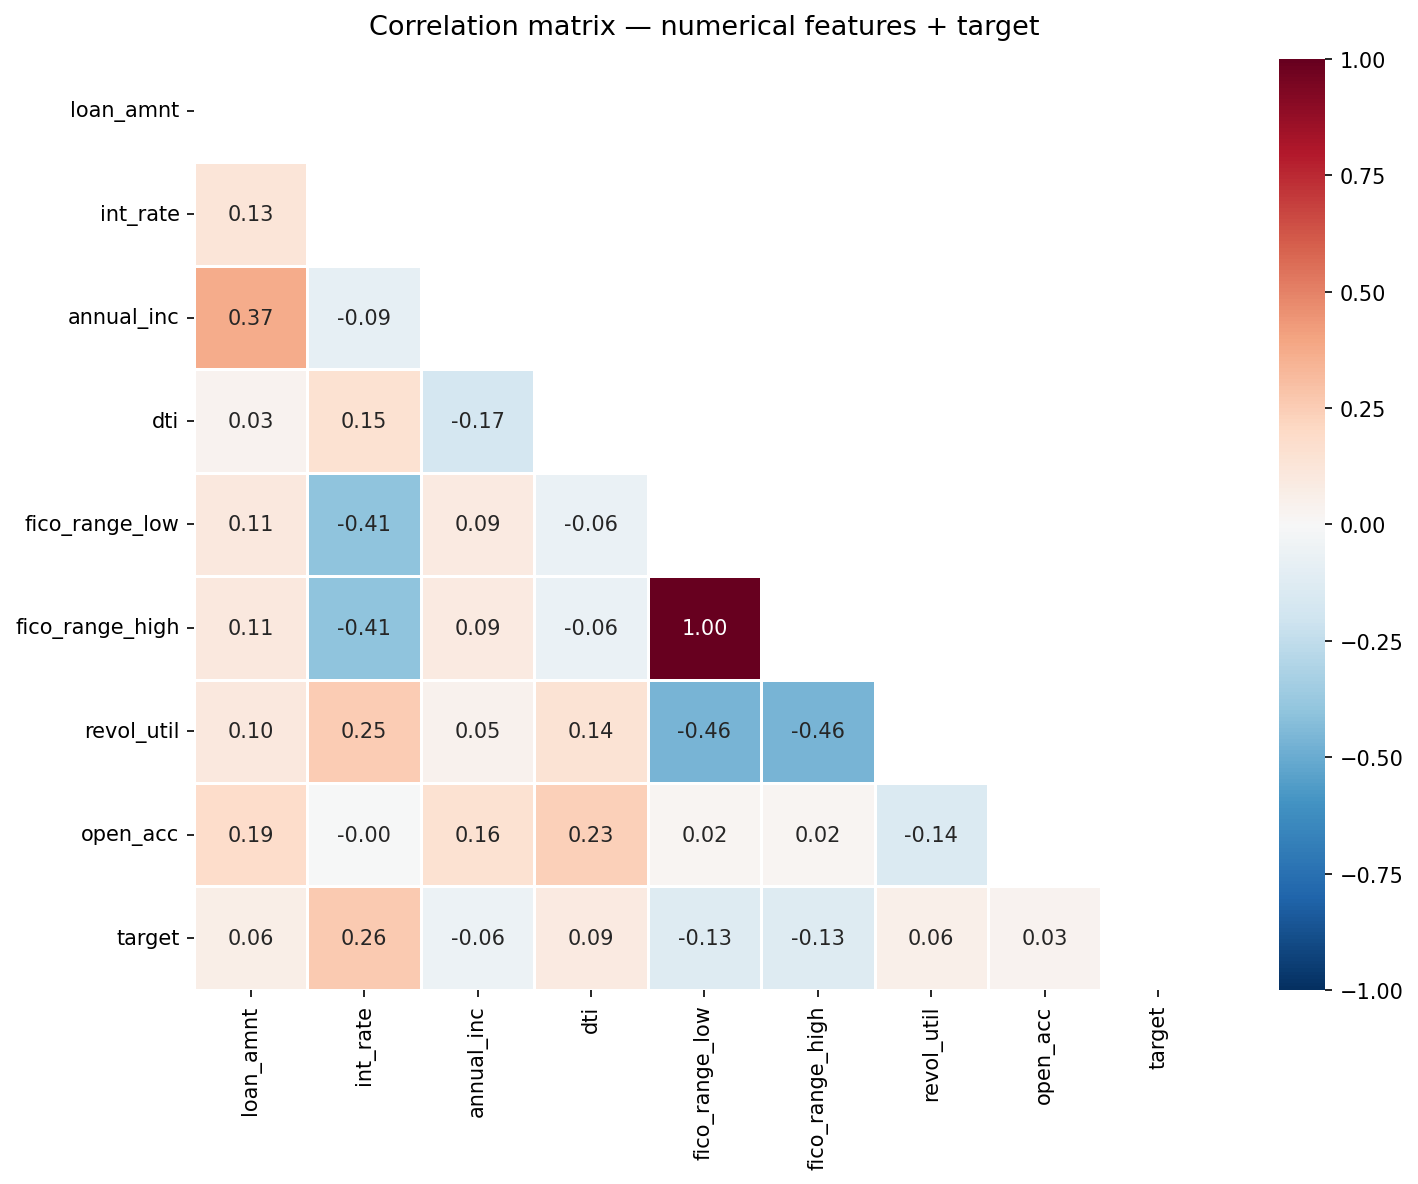


Correlation with target (sorted by absolute value):
  int_rate              +0.260
  fico_range_low        -0.129
  fico_range_high       -0.129
  dti                   +0.086
  loan_amnt             +0.065
  annual_inc            -0.058
  revol_util            +0.057
  open_acc              +0.035


In [9]:
# Build correlation matrix on a sample for speed (full dataset is slow)
sample = df[NUMERICAL + ['target']].dropna().sample(
    n=min(50_000, len(df)), random_state=42
)

corr = sample.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 10},
    ax=ax
)

ax.set_title('Correlation matrix — numerical features + target', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Print high correlations with target
target_corr = corr['target'].drop('target').sort_values(key=abs, ascending=False)
print("\nCorrelation with target (sorted by absolute value):")
for feat, val in target_corr.items():
    direction = "+" if val > 0 else "-"
    print(f"  {feat:20s}  {direction}{abs(val):.3f}")

Cell 10 — Multicollinearity check: FICO high vs low

In [10]:
# fico_range_low and fico_range_high are almost perfectly correlated
# You'll drop one in preprocessing — confirm here
fico_corr = df[['fico_range_low','fico_range_high']].corr().iloc[0,1]
print(f"Correlation between fico_range_low and fico_range_high: {fico_corr:.4f}")
print("→ Drop fico_range_high in preprocessing, keep fico_range_low only")

int_grade_corr = df[['int_rate']].join(
    df['grade'].map({'A':1,'B':2,'C':3,'D':4,'E':5,'F':6,'G':7})
).corr().iloc[0,1]
print(f"\nCorrelation between int_rate and grade (encoded): {int_grade_corr:.4f}")
print("→ High multicollinearity — keep both but note in model card")

Correlation between fico_range_low and fico_range_high: 1.0000
→ Drop fico_range_high in preprocessing, keep fico_range_low only

Correlation between int_rate and grade (encoded): 0.9533
→ High multicollinearity — keep both but note in model card


Cell 11 — Geographic default rate by state

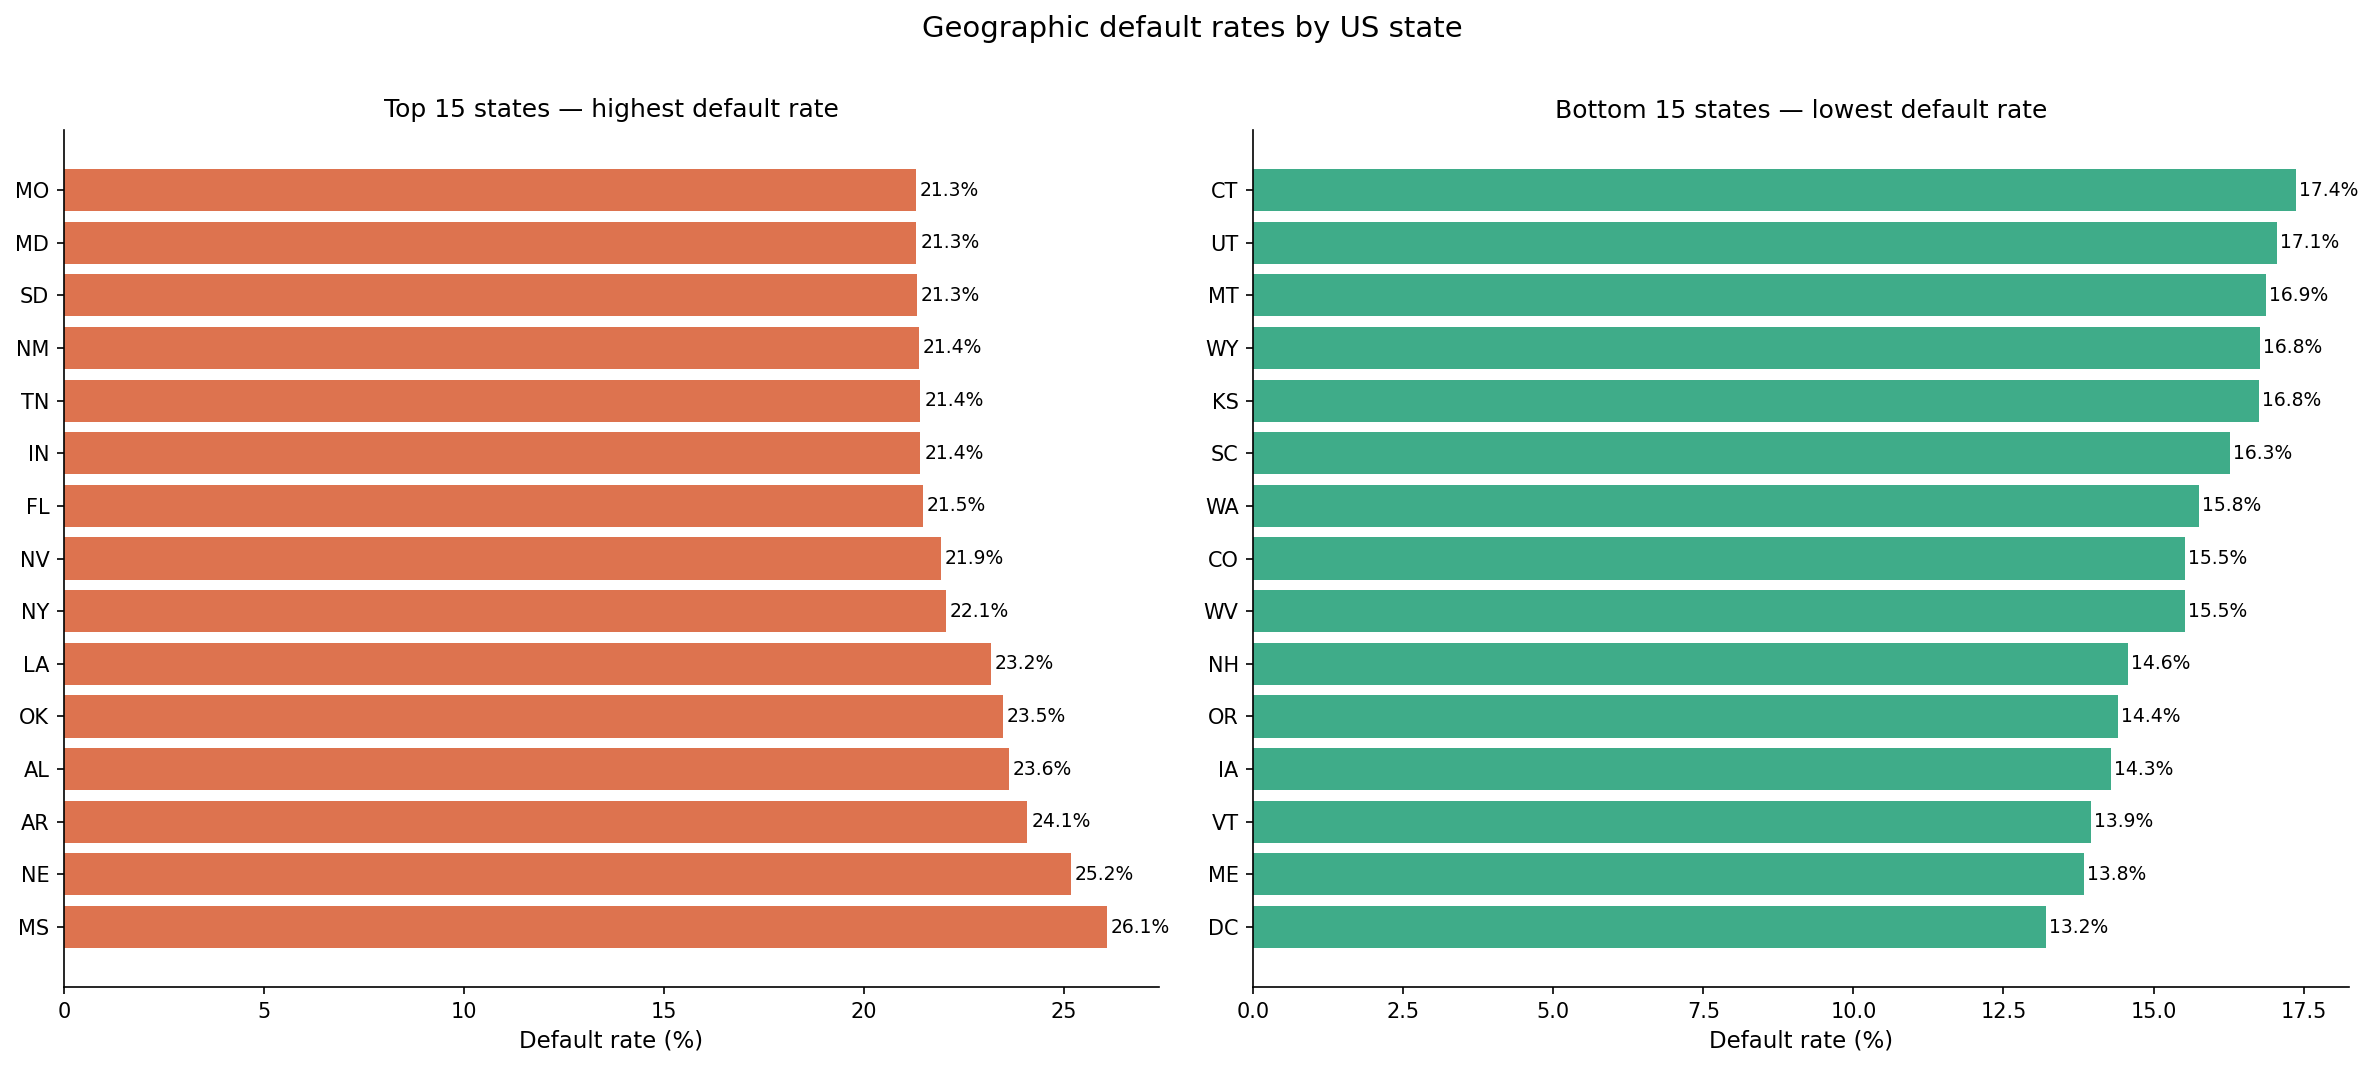


Full state default rate table:
addr_state  default_rate      n  default_rate_pct
        MS      0.260777   6588             26.08
        NE      0.251813   3586             25.18
        AR      0.240868  10047             24.09
        AL      0.236321  16613             23.63
        OK      0.234753  12281             23.48
        LA      0.231821  15499             23.18
        NY      0.220484 109849             22.05
        NV      0.219223  20267             21.92
        FL      0.214787  95611             21.48
        IN      0.214082  21716             21.41
        TN      0.214079  20385             21.41
        NM      0.213665   7362             21.37
        SD      0.213227   2767             21.32
        MD      0.213110  31228             21.31
        MO      0.212972  21261             21.30
        NJ      0.211228  48450             21.12
        KY      0.209829  12839             20.98
        PA      0.207956  45524             20.80
        NC      0.

In [11]:
state_stats = (
    df.groupby('addr_state')['target']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'default_rate', 'count': 'n'})
    .reset_index()
    .sort_values('default_rate', ascending=False)
)
state_stats['default_rate_pct'] = (state_stats['default_rate'] * 100).round(2)

# ── Top 15 and bottom 15 states ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top15    = state_stats.head(15)
bottom15 = state_stats.tail(15).sort_values('default_rate_pct')

axes[0].barh(top15['addr_state'], top15['default_rate_pct'],
             color=CORAL, alpha=0.85)
axes[0].set_title('Top 15 states — highest default rate', fontsize=12)
axes[0].set_xlabel('Default rate (%)')
for i, (_, row) in enumerate(top15.iterrows()):
    axes[0].text(row['default_rate_pct'] + 0.1, i,
                 f"{row['default_rate_pct']:.1f}%", va='center', fontsize=9)

axes[1].barh(bottom15['addr_state'], bottom15['default_rate_pct'],
             color=TEAL, alpha=0.85)
axes[1].set_title('Bottom 15 states — lowest default rate', fontsize=12)
axes[1].set_xlabel('Default rate (%)')
for i, (_, row) in enumerate(bottom15.iterrows()):
    axes[1].text(row['default_rate_pct'] + 0.05, i,
                 f"{row['default_rate_pct']:.1f}%", va='center', fontsize=9)

plt.suptitle('Geographic default rates by US state', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'default_rate_by_state.png', bbox_inches='tight')
plt.show()

print("\nFull state default rate table:")
print(state_stats.sort_values('default_rate_pct', ascending=False).to_string(index=False))

Cell 12 — US choropleth map (state-level default rates)


In [12]:
# Uses plotly — no additional install needed (already in requirements)
import plotly.graph_objects as go

fig = go.Figure(data=go.Choropleth(
    locations=state_stats['addr_state'],
    z=state_stats['default_rate_pct'],
    locationmode='USA-states',
    colorscale='RdYlGn_r',
    colorbar_title='Default rate (%)',
    text=state_stats.apply(
        lambda r: f"{r['addr_state']}: {r['default_rate_pct']:.1f}% ({r['n']:,} loans)",
        axis=1
    ),
    hovertemplate='%{text}<extra></extra>'
))

fig.update_layout(
    title_text='LendingClub default rate by US state (2007–2018)',
    title_x=0.5,
    geo_scope='usa',
    margin=dict(l=0, r=0, t=40, b=0),
    height=450
)

fig.write_html(str(REPORTS_DIR / 'default_rate_map.html'))
fig.show()
print("Saved interactive map: reports/default_rate_map.html")

Saved interactive map: reports/default_rate_map.html


Cell 13 — Default rate over time (yearly trend)

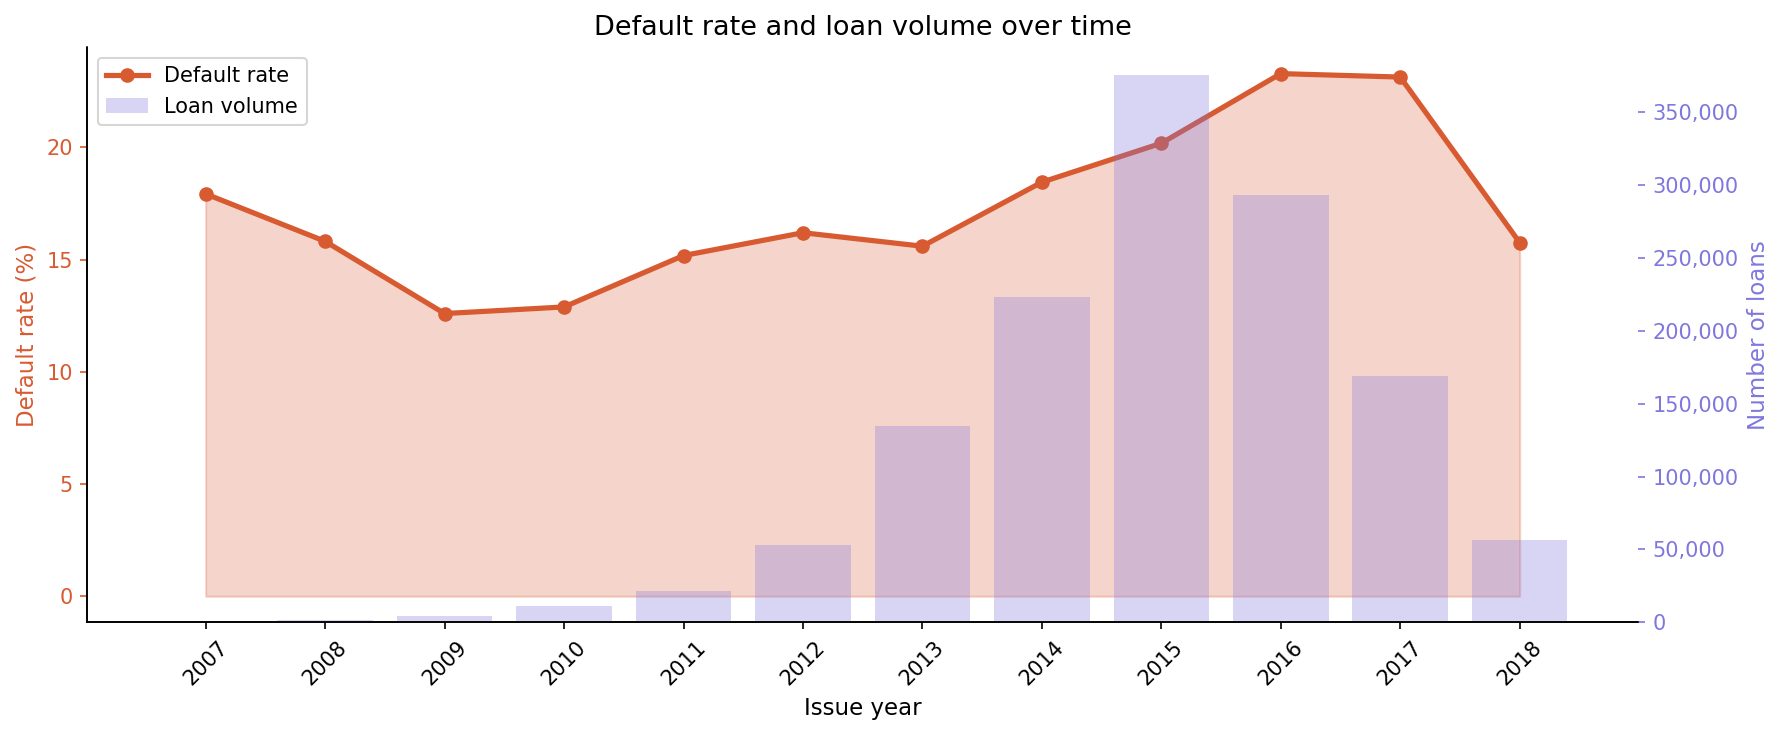


Note: 2007-2009 high default rate = GFC cohort
Note: 2016-2018 low default rate = loans may not have fully seasoned yet
→ This validates why temporal split (not random split) is critical


In [13]:
time_stats = (
    df.groupby('issue_year')['target']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'default_rate', 'count': 'n'})
    .reset_index()
)
time_stats['default_rate_pct'] = time_stats['default_rate'] * 100

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.fill_between(time_stats['issue_year'], time_stats['default_rate_pct'],
                 alpha=0.25, color=CORAL)
ax1.plot(time_stats['issue_year'], time_stats['default_rate_pct'],
         color=CORAL, marker='o', linewidth=2.5, label='Default rate')

ax2.bar(time_stats['issue_year'], time_stats['n'],
        alpha=0.3, color=PURPLE, label='Loan volume')

ax1.set_xlabel('Issue year')
ax1.set_ylabel('Default rate (%)', color=CORAL)
ax2.set_ylabel('Number of loans', color=PURPLE)
ax1.tick_params(axis='y', colors=CORAL)
ax2.tick_params(axis='y', colors=PURPLE)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

ax1.set_title('Default rate and loan volume over time', fontsize=13)
ax1.set_xticks(time_stats['issue_year'])
ax1.set_xticklabels(time_stats['issue_year'], rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'default_rate_over_time.png', bbox_inches='tight')
plt.show()

print("\nNote: 2007-2009 high default rate = GFC cohort")
print("Note: 2016-2018 low default rate = loans may not have fully seasoned yet")
print("→ This validates why temporal split (not random split) is critical")

Cell 14 — EDA summary findings (write these into your model card)

In [14]:
findings = {
    "Default rate"         : f"{df['target'].mean():.2%} overall",
    "Class imbalance"      : f"{(1-df['target'].mean())/(df['target'].mean()):.1f}:1 paid-to-default ratio",
    "Strongest predictor"  : "int_rate (higher rate → higher default — confirmed by correlation and grade chart)",
    "Grade monotonicity"   : "Default rate increases monotonically from A to G — validates LC grading system",
    "FICO collinearity"    : "fico_range_low and fico_range_high corr > 0.99 — drop high, keep low",
    "int_rate vs grade"    : "Corr > 0.95 — multicollinear, keep both but note in model card",
    "Geographic risk"      : "State-level default rates vary by ~10pp — important for fairness audit",
    "Temporal trend"       : "GFC cohort (2007-09) shows elevated defaults — validates temporal split choice",
    "annual_inc skew"      : "Extreme right skew — log-transform required before modeling",
    "Top purpose risk"     : "Small business loans have highest default rate among purposes",
}

print("=== EDA FINDINGS FOR MODEL CARD ===\n")
for k, v in findings.items():
    print(f"  {k:25s}  {v}")

=== EDA FINDINGS FOR MODEL CARD ===

  Default rate               19.96% overall
  Class imbalance            4.0:1 paid-to-default ratio
  Strongest predictor        int_rate (higher rate → higher default — confirmed by correlation and grade chart)
  Grade monotonicity         Default rate increases monotonically from A to G — validates LC grading system
  FICO collinearity          fico_range_low and fico_range_high corr > 0.99 — drop high, keep low
  int_rate vs grade          Corr > 0.95 — multicollinear, keep both but note in model card
  Geographic risk            State-level default rates vary by ~10pp — important for fairness audit
  Temporal trend             GFC cohort (2007-09) shows elevated defaults — validates temporal split choice
  annual_inc skew            Extreme right skew — log-transform required before modeling
  Top purpose risk           Small business loans have highest default rate among purposes
